In [1]:
import torch
import torch.nn as nn
import torch_pruning as tp
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torch.nn.utils.prune as prune
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

from tqdm import tqdm
import numpy as np
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

### This code uses the Imagenette2 dataset. The link to download it:
https://github.com/fastai/imagenette 

## Data Preparation 

In [2]:
class_mapping = {
    'n01440764': { 1 : 'tench'},
    'n02102040': { 2 : 'English_springer'},
    'n02979186': { 3 : 'cassette_player'},
    'n03000684': { 4 : 'chain saw'},
    'n03028079': { 5 : 'church'},
    'n03394916': { 6 : 'French horn'},
    'n03417042': { 7 : 'garbage truck'},
    'n03425413': { 8 : 'gas pump'},
    'n03445777': { 9 : 'golf ball'},
    'n03888257': { 10 : 'parachute'}
}

In [3]:
class_names = [list(v.values())[0] for v in class_mapping.values()]

In [49]:
train_dir = "./imagenette2/train"
val_dir = "./imagenette2/val" 

In [50]:
def create_df(dataset_path): 
    data = []

    for class_folder in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_folder)

        if os.path.isdir(class_path) and class_folder in class_mapping:
            class_id, class_name = list(class_mapping[class_folder].items())[0]

            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)

                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                except:
                     print('Unreadable file') 

                data.append([img_path, class_name, width, height, class_id])

    df = pd.DataFrame(data, columns=["image_path", "class_name", "width", "height", "class_id"])
    
    return df

In [51]:
train_df = create_df(train_dir)
val_df = create_df(val_dir)

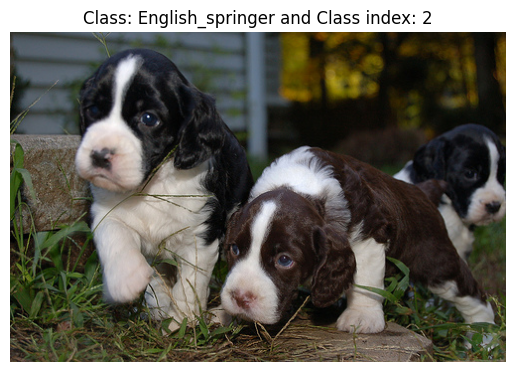

In [7]:
random_row_train = train_df.sample(n=1).iloc[0]

image_path_train = random_row_train.image_path
class_name_train = random_row_train.class_name
class_id_train = random_row_train.class_id

img = Image.open(image_path_train)
plt.imshow(img)
plt.axis("off")  
plt.title(f"Class: {class_name_train} and Class index: {class_id_train}")
plt.show()

## Augmentation

In [7]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

## Loading the dataset

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
class MAINDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        self.df["class_id"] = self.df["class_id"] - self.df["class_id"].min()  

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]

        image = Image.open(img_path).convert("RGB")

        label = int(self.df.iloc[idx]["class_id"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_dataset = MAINDataset(train_df, transform=transform_train)
val_dataset = MAINDataset(val_df, transform=transform_val)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Preparating the model and additional classes

In [12]:
class CustomDropout(nn.Module):
    def __init__(self, p=0.5):
        super(CustomDropout, self).__init__()
        self.default_p = p

    def forward(self, x, seed=None, p=None):
        dropout_p = self.default_p if p is None else p
        if seed is not None:
            torch.manual_seed(seed)
        if self.training:
            batch_size, output_nb_neurons = x.size()
            mask = (torch.rand(1, output_nb_neurons) > dropout_p).float().to(x.device)
            x = x * mask
            return x / (1 - dropout_p)
        else:
            return x

In [13]:
class SpatialDropout(nn.Module):
    def __init__(self, p=0.5):
        super(SpatialDropout, self).__init__()
        self.default_p = p

    def forward(self, x, seed=None, p=None):
        dropout_p = self.default_p if p is None else p
        if seed is not None:
            torch.manual_seed(seed)
        if self.training:
            batch_size, channels, height, width = x.size()
            mask = (torch.rand(1, channels, 1, 1) > dropout_p).float().to(x.device)
            x = x * mask
            return x / (1 - dropout_p)
        else:
            return x

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.spatial_dropout1 = SpatialDropout(p=0.5)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.spatial_dropout2 = SpatialDropout(p=0.5)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.spatial_dropout3 = SpatialDropout(p=0.5)
        self.fc1 = nn.Linear(256 * 16 * 16, 512)
        self.dropout = CustomDropout(p=0.5)
        self.fc2 = nn.Linear(512, 10) 

    def forward(self, x, seed=None, dropout_p=None):
        x = F.relu(self.conv1(x))
        x = self.spatial_dropout1(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = self.spatial_dropout2(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = self.spatial_dropout3(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x, seed=seed, p=dropout_p)
        x = self.fc2(x)
        return x

In [15]:
model = SimpleCNN().to(device)

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,  weight_decay=1e-4)

## Training and Validation functions
### No Fixed Seed

In [ ]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loader_tqdm = tqdm(train_loader, desc="Training")

    before_weights = {
        name: param.clone().detach()
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    for images, labels in train_loader_tqdm:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0) 
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        avg_loss = running_loss / total if total > 0 else 0.0
        train_loader_tqdm.set_postfix(loss=f"{avg_loss:.4f}")

    weights_updated = any( not torch.equal(before_weights[name], param.detach())
                           for name, param in model.named_parameters() if param.requires_grad)

    print("Weights are updated!" if weights_updated else "PROBLEM: Weights did not update!")

    train_loss = running_loss / total if total > 0 else 0.0
    train_acc = 100 * correct / total if total > 0 else 0.0
    return train_loss, train_acc

In [19]:
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    val_loader_tqdm = tqdm(val_loader, desc="Validation")

    with torch.no_grad():
        for images, labels in val_loader_tqdm:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            val_loader_tqdm.set_postfix(loss=f"{running_loss / total:.4f}")

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, patience=5):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} ----------------------------")

        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'initial_trained_model.pth')
            print("Saved new best model!")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs.")

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if epochs_no_improve == patience:
            print("Early stopping!")
            break

    return train_losses, val_losses, train_accuracies, val_accuracies

### Model training

In [22]:
num_epochs = 20 
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
   model, train_loader, val_loader, criterion, optimizer, num_epochs
)


Epoch 1/20 ----------------------------


Training: 100%|██████████| 148/148 [02:53<00:00,  1.18s/it, loss=2.2926]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:29<00:00,  2.13it/s, loss=0.0338]


Saved new best model!
Epoch 1/20: Train Loss: 2.2926, Train Acc: 17.90%, Val Loss: 2.1378, Val Acc: 28.15%

Epoch 2/20 ----------------------------


...

Saved new best model!
Epoch 19/20: Train Loss: 1.5298, Train Acc: 49.56%, Val Loss: 1.4412, Val Acc: 54.34%

Epoch 20/20 ----------------------------


Training: 100%|██████████| 148/148 [03:12<00:00,  1.30s/it, loss=1.5353]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:35<00:00,  1.75it/s, loss=0.0219]


Saved new best model!
Epoch 20/20: Train Loss: 1.5353, Train Acc: 49.43%, Val Loss: 1.3869, Val Acc: 57.50%


### Continuing training to improve model performance

In [23]:
model.load_state_dict(torch.load('initial_trained_model.pth'))
print("Model loaded successfully")

Model loaded successfully


In [24]:
new_optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

In [ ]:
def continue_training(model, train_loader, val_loader, criterion, optimizer, start_epoch, num_extra_epochs, patience=5):
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(start_epoch, start_epoch + num_extra_epochs):
        print(f"\nEpoch {epoch+1} ----------------------------")

        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'initial_trained_model.pth')
            print("Saved new best model!")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs.")

        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if epochs_no_improve == patience:
            print("Early stopping!")
            break


In [ ]:
continue_training(model, train_loader, val_loader, criterion, new_optimizer, start_epoch=20, num_extra_epochs=15)


Epoch 21 ----------------------------


Training: 100%|██████████| 148/148 [02:56<00:00,  1.19s/it, loss=1.4320]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:33<00:00,  1.87it/s, loss=0.0207]


Saved new best model!
Epoch 21: Train Loss: 1.4320, Train Acc: 52.98%, Val Loss: 1.3093, Val Acc: 58.37%

Epoch 22 ----------------------------


...

No improvement for 2 epochs.
Epoch 34: Train Loss: 1.0825, Train Acc: 64.36%, Val Loss: 1.1627, Val Acc: 62.98%

Epoch 35 ----------------------------


Training: 100%|██████████| 148/148 [03:14<00:00,  1.31s/it, loss=1.0372]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:35<00:00,  1.75it/s, loss=0.0178]


Saved new best model!
Epoch 35: Train Loss: 1.0372, Train Acc: 65.80%, Val Loss: 1.1290, Val Acc: 63.77%


In [ ]:
continue_training(model, train_loader, val_loader, criterion, new_optimizer, start_epoch=35, num_extra_epochs=5)


Epoch 36 ----------------------------


Training: 100%|██████████| 148/148 [03:16<00:00,  1.33s/it, loss=1.0215]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:35<00:00,  1.75it/s, loss=0.0174]


Saved new best model!
Epoch 36: Train Loss: 1.0215, Train Acc: 66.45%, Val Loss: 1.0998, Val Acc: 64.94%

Epoch 37 ----------------------------


...

Saved new best model!
Epoch 39: Train Loss: 0.9447, Train Acc: 69.42%, Val Loss: 1.0567, Val Acc: 66.24%

Epoch 40 ----------------------------


Training: 100%|██████████| 148/148 [03:02<00:00,  1.24s/it, loss=0.9158]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:33<00:00,  1.83it/s, loss=0.0173]

No improvement for 1 epochs.
Epoch 40: Train Loss: 0.9158, Train Acc: 69.90%, Val Loss: 1.0982, Val Acc: 64.69%


In [ ]:
continue_training(model, train_loader, val_loader, criterion, new_optimizer, start_epoch=40, num_extra_epochs=5)


Epoch 41 ----------------------------


Training: 100%|██████████| 148/148 [02:48<00:00,  1.14s/it, loss=0.8714]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:29<00:00,  2.08it/s, loss=0.0164]


Saved new best model!
Epoch 41: Train Loss: 0.8714, Train Acc: 71.57%, Val Loss: 1.0358, Val Acc: 67.18%

Epoch 42 ----------------------------


...

Saved new best model!
Epoch 44: Train Loss: 0.7773, Train Acc: 74.33%, Val Loss: 1.0266, Val Acc: 67.80%

Epoch 45 ----------------------------


Training: 100%|██████████| 148/148 [03:04<00:00,  1.25s/it, loss=0.7729]


Weights are updated!


Validation: 100%|██████████| 62/62 [00:34<00:00,  1.80it/s, loss=0.0162]


Saved new best model!
Epoch 45: Train Loss: 0.7729, Train Acc: 74.75%, Val Loss: 1.0233, Val Acc: 67.69%


# Experiment 1.A: Comparison of Dropout-based vs. L2-Norm Pruning (No Mask Control)

### Dropout-based Pruning part

In [17]:
def generate_dropout_mask_for_pruning(module, dropout_rate, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    if isinstance(module, nn.Linear):
        output_nb_neurons, _ = module.weight.size()
        mask = (torch.rand(1, output_nb_neurons) > dropout_rate).float()
        mask /= (1 - dropout_rate)
    elif isinstance(module, nn.Conv2d):

        channels_output, _, _, _ = module.weight.size()
        mask = (torch.rand(1, channels_output, 1, 1) > dropout_rate).float()
        mask /= (1 - dropout_rate)  
    else:
        raise ValueError("Unknown dropout layer type")
    
    return mask

In [18]:
def prune_model_based_on_dropout(model, dropout_rate, seed=None):
    mask_list = []
    for name, module in model.named_children():
        
        if isinstance(module, nn.Linear): 
          
            mask = generate_dropout_mask_for_pruning(module, dropout_rate, seed)
            mask_list.append(torch.flatten(mask))
        
        elif isinstance(module, nn.Conv2d): 

            mask = generate_dropout_mask_for_pruning(module, dropout_rate, seed)
            mask_list.append(torch.flatten(mask))
            
        elif isinstance(module, CustomDropout):  
            pass
        
        elif isinstance(module, SpatialDropout):
            pass
        
        else: 
            pass
            
    example_inputs = torch.randn(1, 3, 128, 128).to(next(model.parameters()).device)
    model(example_inputs)
    
    DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)
    
    mask_index = 0
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d): 
            mask = mask_list[mask_index]
            mask_index += 1
            prune_indices = np.where(mask == 0)[0]

            group = DG.get_pruning_group(module, tp.prune_conv_out_channels, prune_indices)

            group.prune()
            
            scaling_factor = 1 / (1 - dropout_rate)
            with torch.no_grad():
                module.weight.data *= scaling_factor
                if module.bias is not None:
                    module.bias.data *= scaling_factor

            
        if isinstance(module, nn.Linear) and not name == "fc2": 
            mask = mask_list[mask_index]
            mask_index += 1
            prune_indices = np.where(mask == 0)[0]

            group = DG.get_pruning_group(module, tp.prune_linear_out_channels, prune_indices)
            
            group.prune()
            
            scaling_factor = 1 / (1 - dropout_rate)
            with torch.no_grad():
                module.weight.data *= scaling_factor
                if module.bias is not None:
                    module.bias.data *= scaling_factor
    print("Model pruned.")
    return model

In [19]:
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seed = 42
results = []

In [20]:
for dropout_rate in dropout_rates:
    print(f"\n=== Pruning with dropout_rate = {dropout_rate} ===")

    exp_model = SimpleCNN().to(device)
    exp_model.load_state_dict(torch.load('initial_trained_model.pth'))

    pruned_model = prune_model_based_on_dropout(exp_model, dropout_rate, seed)

    total_params = sum(p.numel() for p in pruned_model.parameters())
    trainable_params = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)

    pruned_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pruned_model(inputs, seed=seed, dropout_p=0.0) 
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    results.append({
        'dropout_rate': dropout_rate,
        'accuracy': accuracy,
        'trainable_params': trainable_params
    })

df_DROPOUT_mask = pd.DataFrame(results)

print("\n=== Pruning Results DataFrame ===")
print(df_DROPOUT_mask)


=== Pruning with dropout_rate = 0.0 ===
Model pruned.

=== Pruning with dropout_rate = 0.1 ===
Model pruned.

=== Pruning with dropout_rate = 0.2 ===
Model pruned.

=== Pruning with dropout_rate = 0.3 ===
Model pruned.

=== Pruning with dropout_rate = 0.4 ===
Model pruned.

=== Pruning with dropout_rate = 0.5 ===
Model pruned.

=== Pruning with dropout_rate = 0.6 ===
Model pruned.

=== Pruning with dropout_rate = 0.7 ===
Model pruned.

=== Pruning with dropout_rate = 0.8 ===
Model pruned.

=== Pruning with dropout_rate = 0.9 ===
Model pruned.

=== Pruning Results DataFrame ===
   dropout_rate   accuracy  trainable_params
0           0.0  67.694268          33930890
1           0.1  67.286624          27519791
2           0.2  65.757962          20708747
3           0.3  62.649682          15048129
4           0.4  56.458599           9751370
5           0.5  53.044586           7125688
6           0.6  47.770701           4998886
7           0.7  40.407643           2362129
8         

In [21]:
df_DROPOUT_mask['sparsity_%'] = 100 * (1 - df_DROPOUT_mask['trainable_params'] / df_DROPOUT_mask['trainable_params'].iloc[0])

In [22]:
df_DROPOUT_mask

,dropout_rate,accuracy,trainable_params,sparsity_%
0,0.0,67.694268,33930890,0.000000
1,0.1,67.286624,27519791,18.894580
2,0.2,65.757962,20708747,38.967864
3,0.3,62.649682,15048129,55.650650
4,0.4,56.458599,9751370,71.261084
5,0.5,53.044586,7125688,78.999407
6,0.6,47.770701,4998886,85.267448
7,0.7,40.407643,2362129,93.038411
8,0.8,19.082803,1016185,97.005133
9,0.9,16.484076,324981,99.042227


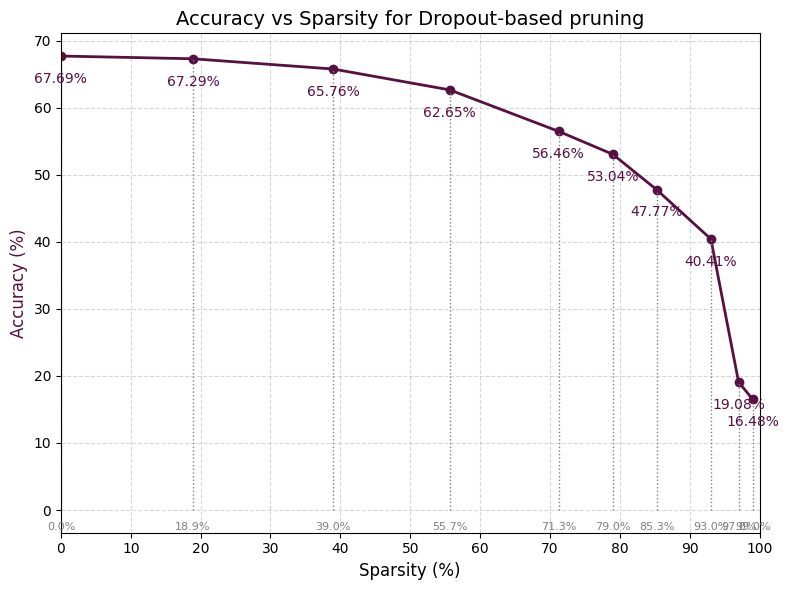

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#580F41', '#FF81C0']

ax.plot(df_DROPOUT_mask['sparsity_%'], df_DROPOUT_mask['accuracy'],
        marker='o', color=palette[0], linewidth=2)

ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12, color=palette[0])
ax.set_title('Accuracy vs Sparsity for Dropout-based pruning', fontsize=14)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.grid(True, linestyle='--', alpha=0.5)
 
for x, y in zip(df_DROPOUT_mask['sparsity_%'], df_DROPOUT_mask['accuracy']):
    ax.annotate(f"{y:.2f}%", (x, y - 4), ha='center', fontsize=10, color=palette[0])  # під точкою
    ax.vlines(x=x, ymin=0, ymax=y, linestyles='dotted', colors='gray', linewidth=1)
    ax.text(x, -3, f"{x:.1f}%", ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("code_fotos/dropout_normal_sparsity.pdf", format='pdf')
plt.show()

### L2-Norm Pruning part

In [25]:
def l2_structured_prune_model(model, pruning_ratio, input_size=(1, 3, 128, 128), skip_last_linear=True):
    example_inputs = torch.randn(*input_size).to(next(model.parameters()).device)
    model(example_inputs)
    DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)

    pruning_results = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weight_copy = module.weight.detach().abs().pow(2).sum(dim=(1, 2, 3))
            num_filters = module.out_channels
            num_prune = int(pruning_ratio * num_filters)

            if num_prune == 0 or num_filters <= 1:
                print(f"Skipped pruning {name} (too small or ratio too low)")
                pruning_results.append({
                    'Layer': name,
                    'Type': 'Conv2d',
                    'Original Units': num_filters,
                    'Pruned Units': 0,
                    'Pruned %': 0.0
                })
                continue

            prune_indices = weight_copy.argsort()[:num_prune].tolist()
            group = DG.get_pruning_group(module, tp.prune_conv_out_channels, prune_indices)
            group.prune()
            pruned_percent = 100.0 * num_prune / num_filters
            print(f"Pruned {num_prune}/{num_filters} filters ({pruned_percent:.2f}%) in {name}")

            pruning_results.append({
                'Layer': name,
                'Type': 'Conv2d',
                'Original Units': num_filters,
                'Pruned Units': num_prune,
                'Pruned %': pruned_percent
            })

        elif isinstance(module, nn.Linear) and module.out_features > 1:
            if skip_last_linear:
                if name == 'fc2':
                    print(f"Skipped pruning {name} (last output layer)")
                    pruning_results.append({
                        'Layer': name,
                        'Type': 'Linear',
                        'Original Units': module.out_features,
                        'Pruned Units': 0,
                        'Pruned %': 0.0
                    })
                    continue

            weight_copy = module.weight.detach().abs().pow(2).sum(dim=1)
            num_units = module.out_features
            num_prune = int(pruning_ratio * num_units)

            if num_prune == 0:
                print(f"Skipped pruning {name} (ratio too low)")
                pruning_results.append({
                    'Layer': name,
                    'Type': 'Linear',
                    'Original Units': num_units,
                    'Pruned Units': 0,
                    'Pruned %': 0.0
                })
                continue

            prune_indices = weight_copy.argsort()[:num_prune].tolist()
            group = DG.get_pruning_group(module, tp.prune_linear_out_channels, prune_indices)
            group.prune()
            pruned_percent = 100.0 * num_prune / num_units
            print(f"Pruned {num_prune}/{num_units} units ({pruned_percent:.2f}%) in {name}")

            pruning_results.append({
                'Layer': name,
                'Type': 'Linear',
                'Original Units': num_units,
                'Pruned Units': num_prune,
                'Pruned %': pruned_percent
            })

    pruning_df = pd.DataFrame(pruning_results)
    print("Pruning completed.")
    return model, pruning_df

In [26]:
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results_l2_structured = []

model_base = SimpleCNN().to(device)
model_base.load_state_dict(torch.load('initial_trained_model.pth'))
total_params_before_pruning = sum(p.numel() for p in model_base.parameters() if p.requires_grad)

In [27]:
for rate in dropout_rates:
    print(f"\n=== L2 Structured Pruning for dropout_rate = {rate} ===")
    pruning_ratio = rate  

    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load('initial_trained_model.pth'))
    model.eval()

    model, pruning_df = l2_structured_prune_model(model, pruning_ratio)

    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100.0 * correct / total

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pruned_percent = 100 * (1 - trainable_params / total_params_before_pruning)

    result = {
        'dropout_rate_for_pruning': rate,
        'accuracy': accuracy,
        'trainable_params': trainable_params,
        'sparsity_%': pruned_percent,
        'pruning_df': pruning_df
    }
    results_l2_structured.append(result)


=== L2 Structured Pruning for dropout_rate = 0.0 ===
Skipped pruning conv1 (too small or ratio too low)
Skipped pruning conv2 (too small or ratio too low)
Skipped pruning conv3 (too small or ratio too low)
Skipped pruning fc1 (ratio too low)
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.1 ===
Pruned 6/64 filters (9.38%) in conv1
Pruned 12/128 filters (9.38%) in conv2
Pruned 25/256 filters (9.77%) in conv3
Pruned 51/512 units (9.96%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.2 ===
Pruned 12/64 filters (18.75%) in conv1
Pruned 25/128 filters (19.53%) in conv2
Pruned 51/256 filters (19.92%) in conv3
Pruned 102/512 units (19.92%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.3 ===
Pruned 19/64 filters (29.69%) in conv1
Pruned 38/128 filters (29.69%) in conv2
Pruned 76/256 filters (29.69%) in

In [28]:
records = []
for res in results_l2_structured:
    records.append({
        'dropout_rate_for_pruning': res['dropout_rate_for_pruning'],
        'accuracy': res['accuracy'],
        'trainable_params': res['trainable_params'],
        'sparsity_%': res['sparsity_%']
    })

df_L2_structured_overall = pd.DataFrame(records)

In [29]:
df_L2_structured_overall

,dropout_rate_for_pruning,accuracy,trainable_params,sparsity_%
0,0.0,67.694268,33930890,0.000000
1,0.1,67.108280,27570464,18.745238
2,0.2,66.904459,21761323,35.865747
3,0.3,65.273885,16730459,50.692543
4,0.4,63.821656,12281062,63.805659
5,0.5,61.503185,8484682,74.994225
6,0.6,57.426752,5468960,83.882061
7,0.7,43.286624,3072075,90.946082
8,0.8,27.388535,1387931,95.909536
9,0.9,10.063694,350790,98.966163


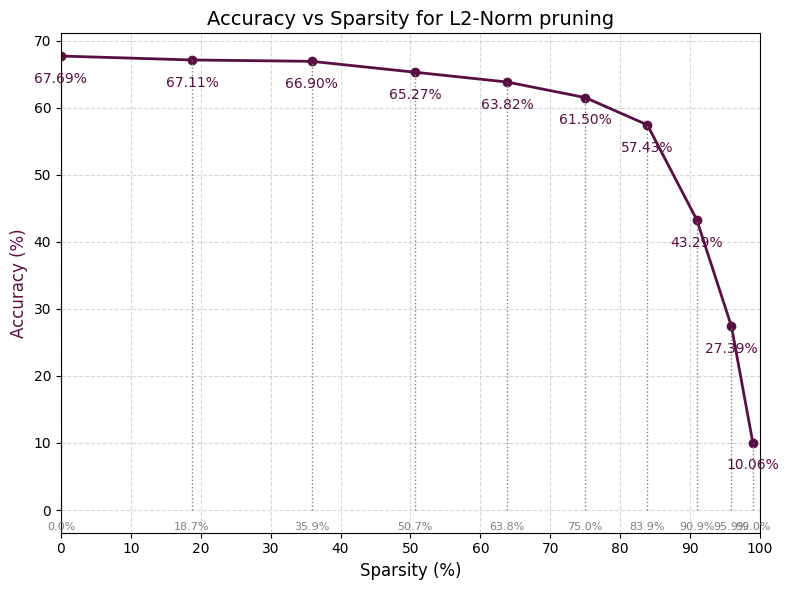

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_L2_structured_overall['sparsity_%'], df_L2_structured_overall['accuracy'],
        marker='o', color=palette[0], linewidth=2)

ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12, color=palette[0])
ax.set_title('Accuracy vs Sparsity for L2-Norm pruning', fontsize=14)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.grid(True, linestyle='--', alpha=0.5)
 
for x, y in zip(df_L2_structured_overall['sparsity_%'], df_L2_structured_overall['accuracy']):
    ax.annotate(f"{y:.2f}%", (x, y - 4), ha='center', fontsize=10, color=palette[0])  # під точкою
    ax.vlines(x=x, ymin=0, ymax=y, linestyles='dotted', colors='gray', linewidth=1)
    ax.text(x, -3, f"{x:.1f}%", ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("code_fotos/l2_normal_sparsity.pdf", format='pdf')
plt.show()

## Comparison of Two Methods

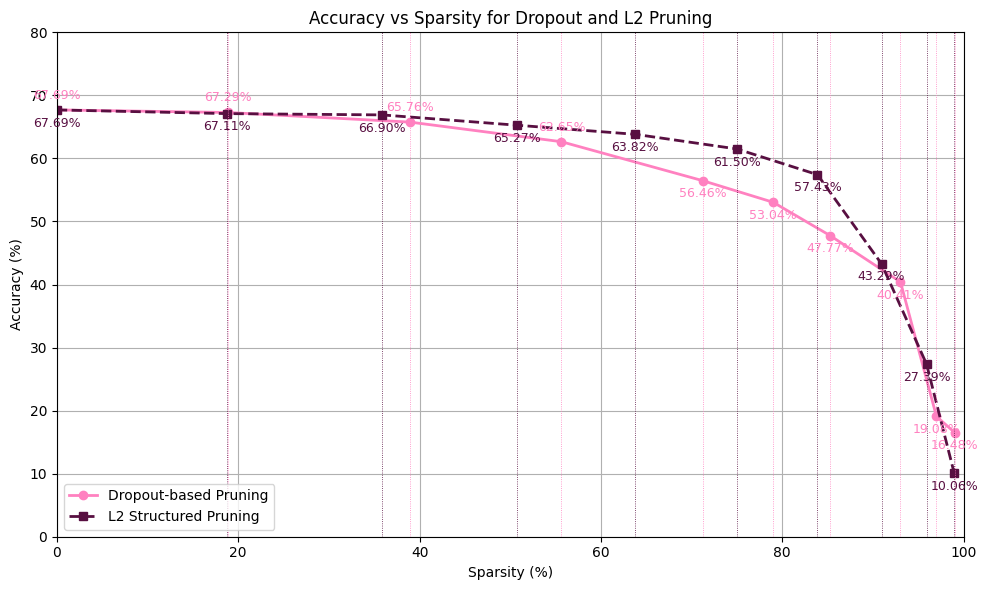

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_DROPOUT_mask['sparsity_%'], df_DROPOUT_mask['accuracy'],
        marker='o', color=palette[1], label='Dropout-based Pruning', linestyle='-', linewidth=2)

ax.plot(df_L2_structured_overall['sparsity_%'], df_L2_structured_overall['accuracy'],
        marker='s', color=palette[0], label='L2 Structured Pruning', linestyle='--', linewidth=2)

ax.set_xlabel('Sparsity (%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Sparsity for Dropout and L2 Pruning')
ax.set_xlim(0, 100)
ax.set_ylim(0, 80)
ax.grid(True)

for i, (x, y) in enumerate(zip(df_DROPOUT_mask['sparsity_%'], df_DROPOUT_mask['accuracy'])):
    ax.annotate(f"{y:.2f}%", (x, y),
                textcoords="offset points",
                xytext=(0, 8 if i < 4 else -12),
                ha='center', color=palette[1], fontsize=9)
    ax.axvline(x=x, color=palette[1], linestyle=':', linewidth=0.6)

for x, y in zip(df_L2_structured_overall['sparsity_%'], df_L2_structured_overall['accuracy']):
    ax.annotate(f"{y:.2f}%", (x, y),
                textcoords="offset points",
                xytext=(0, -12),
                ha='center', color=palette[0], fontsize=9)
    ax.axvline(x=x, color=palette[0], linestyle=':', linewidth=0.6)

ax.legend(loc='lower left')
plt.savefig("code_fotos/comparing_dropout_l2_no_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()


## Fine-Tuning After Pruning: Enhancement of Model Performance
### dropout = 0.5 

In [32]:
def evaluate_model_accuracy(model, val_loader, device, seed=None, dropout_p=0.0):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images, seed=seed, dropout_p=dropout_p) if seed is not None else model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    print(f"Accuracy of pruned model: {accuracy:.2f}%")
    return accuracy

In [33]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if trainable_params == 0:
        print("Warning: No trainable parameters!")
        return

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} ----------------------------")
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        train_loader_tqdm = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False)

        for images, labels in train_loader_tqdm:
            images, labels = images.to(next(model.parameters()).device), labels.to(next(model.parameters()).device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            grads_status = []
            for name, param in model.named_parameters():
                if param.requires_grad:
                    grads_status.append(f"{name}: {'Correct' if param.grad is not None else 'Incorrect'}")
            train_loader_tqdm.set_postfix({
                "loss": f"{loss.item():.4f}",
                "grads": ", ".join(grads_status[:3]) + (" ..." if len(grads_status) > 3 else "")  
            })

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", leave=False)

        with torch.no_grad():
            for images, labels in val_loader_tqdm:
                images, labels = images.to(next(model.parameters()).device), labels.to(next(model.parameters()).device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_loader_tqdm.set_postfix({
                    "val_loss": f"{loss.item():.4f}"
                })

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if scheduler:
            scheduler.step(val_loss)

In [34]:
def fine_tune_pruned_model(model, train_loader, val_loader, device, num_epochs, lr, scheduler_patience=5, use_scheduler=True):
    model.to(device)
    
    for _, param in model.named_parameters():
        param.requires_grad = True  

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=scheduler_patience
        )
    
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs, scheduler=scheduler)
    
    print("Fine-tuning completed.")
    return model


In [35]:
dropout_rate = 0.5
seed = 42

### Fine-tuning for Dropout pruning method

In [36]:
dropout_model = SimpleCNN().to(device)
dropout_model.load_state_dict(torch.load('initial_trained_model.pth'))

pruned_model_dropout = prune_model_based_on_dropout(dropout_model, dropout_rate, seed)

Model pruned.


In [37]:
pruned_model_dropout_accuracy_before = evaluate_model_accuracy(pruned_model_dropout, val_loader=val_loader, device=device)
pruned_model_dropout_accuracy_before

Accuracy of pruned model: 53.04%


53.044585987261144

In [38]:
fine_tuned_model_dropout = fine_tune_pruned_model(
    model = pruned_model_dropout,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs= 10,
    lr=1e-4
)


Epoch 1/10 ----------------------------


Train Loss: 2.3508, Train Acc: 44.59%


Val Loss: 1.3074, Val Acc: 57.71%

Epoch 2/10 ----------------------------


Train Loss: 1.8788, Train Acc: 46.32%


Val Loss: 1.2982, Val Acc: 59.01%

Epoch 3/10 ----------------------------


...

Val Loss: 1.3004, Val Acc: 61.63%

Epoch 9/10 ----------------------------


Train Loss: 1.3980, Train Acc: 54.04%


Val Loss: 1.2879, Val Acc: 62.34%

Epoch 10/10 ----------------------------


Train Loss: 1.3714, Train Acc: 54.92%


Val Loss: 1.2788, Val Acc: 62.55%
Fine-tuning completed.


In [39]:
pruned_model_dropout_accuracy_after = evaluate_model_accuracy(fine_tuned_model_dropout, val_loader=val_loader, device=device)
pruned_model_dropout_accuracy_after

Accuracy of pruned model: 62.55%


62.547770700636946

In [40]:
torch.save(fine_tuned_model_dropout, 'fine_tunned_dropout_model_without_fixed_seed.pth')

### Fine-tuning for L2 pruning method

In [41]:
l2_model = SimpleCNN().to(device)
l2_model.load_state_dict(torch.load('initial_trained_model.pth'))

l2_model.eval()
torch.manual_seed(seed) 

pruned_model_l2, pruning_df = l2_structured_prune_model(
    l2_model,
    pruning_ratio=dropout_rate,
    skip_last_linear=True
)

Pruned 32/64 filters (50.00%) in conv1
Pruned 64/128 filters (50.00%) in conv2
Pruned 128/256 filters (50.00%) in conv3
Pruned 256/512 units (50.00%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.


In [42]:
pruned_model_l2_accuracy_before = evaluate_model_accuracy(pruned_model_l2, val_loader=val_loader, device=device)
pruned_model_l2_accuracy_before

Accuracy of pruned model: 61.50%


61.503184713375795

In [43]:
fine_tuned_model_l2 = fine_tune_pruned_model(
    model = pruned_model_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs= 10,
    lr=1e-4
)


Epoch 1/10 ----------------------------


Train Loss: 1.0461, Train Acc: 66.03%


Val Loss: 1.0847, Val Acc: 65.22%

Epoch 2/10 ----------------------------


Train Loss: 0.9876, Train Acc: 67.62%


Val Loss: 1.0699, Val Acc: 65.63%

Epoch 3/10 ----------------------------


...

Val Loss: 1.0349, Val Acc: 66.50%

Epoch 9/10 ----------------------------


Train Loss: 0.8982, Train Acc: 70.19%


Val Loss: 1.0461, Val Acc: 66.62%

Epoch 10/10 ----------------------------


Train Loss: 0.8944, Train Acc: 70.23%


Val Loss: 1.0364, Val Acc: 66.65%
Fine-tuning completed.


In [44]:
pruned_model_l2_accuracy_after = evaluate_model_accuracy(fine_tuned_model_l2, val_loader=val_loader, device=device)
pruned_model_l2_accuracy_after

Accuracy of pruned model: 66.65%


66.64968152866243

In [45]:
torch.save(fine_tuned_model_l2, 'fine_tunned_l2_model_without_fixed_seed.pth')

In [46]:
methods = ['Dropout Pruning', 'L2 Pruning']
acc_before = [pruned_model_dropout_accuracy_before, pruned_model_l2_accuracy_before]
acc_after = [pruned_model_dropout_accuracy_after, pruned_model_l2_accuracy_after]

df_fine_tuning = pd.DataFrame({
    'Method': methods * 2,
    'Stage': ['Before Fine-tuning'] * 2 + ['After Fine-tuning'] * 2,
    'Accuracy': acc_before + acc_after
})

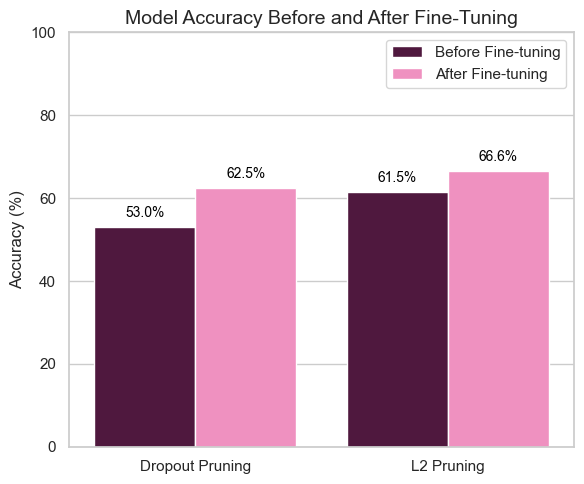

In [48]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=df_fine_tuning,
    x='Method',
    y='Accuracy',
    hue='Stage',
    palette= palette
)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.title('Model Accuracy Before and After Fine-Tuning', fontsize=14)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.xlabel('')
plt.legend(title='', loc='upper right')
plt.savefig("code_fotos/fine_tuned_no_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()

## All models created and used in this work are available at the following link:
https://www.kaggle.com/models/semenetsdaryna/dropout-for-neural-network-pruning